In [4]:
import os
import numpy as np
import pandas as pd
from scipy.optimize import fsolve

from Frechet import interactive_plot, plot_frechet_gumbel
from main_simulate import eqm 

SCRIPT_DIR = os.path.abspath('.')
RAW_DIR = os.path.join(SCRIPT_DIR, "data", "raw")
print("Path set successfully.")

Path set successfully.


# 1. Eaton & Kortum (2002) and Some Extension

## 1.1 Motivation
Classical trade theories (Ricardo, Heckscher-Ohlin), while extremely useful in highlighting the economic forces behind trade, are very difficult to generalize to a set-up with many trading partners and bilateral trade costs. The classical theories do not provide much guidance in doing empirical work (lack of quantifiability). 

Because of this difficulty, those doing empirical work in trade began using a statistical model known as the gravity equation. It is no exaggeration to say that the gravity equation is one of the most successful empirical relationships in all of economics.

Despite the gravity equation's empirical success, its lack of theoretical foundations and interpretability long limited its use for policy analysis or counterfactual predictions. This gap between empirical relevance and theoretical rigor motivated the development of new models that could both explain the gravity relationship and provide a structural basis.

The Eaton-Kortum (henceforth EK) model, rooted in the Ricardian tradition, addresses this need by introducing a probabilistic representation of productivity differences across countries and goods. It not only provides a micro-founded derivation of the gravity equation but also incorporates bilateral trade costs and multiple countries naturally, making it fully consistent with real-world trade patterns. 

## 1.2 Basic Settings
- A finite number of countries $S = \{1, ..., N\}$.
- A continuum of goods $\Omega$. 
- Countries vary (exogenously) in the productivity $z_i (\omega)$, $i \in S$, $\omega \in \Omega$.
- For any $i \in S$ and any $\omega \in \Omega$, $z_i (\omega)$ follows a Fréchet distribution, 
\begin{equation*}
	F_i(z) = \exp(-T_i z^{-\theta}).  
\end{equation*}
- $T_i > 0$ is a measure of the aggregate productivity **(absolute advantage)** of country $i$.
- $\theta > 1$ (constant across countries) is a measure of the **inverse** dispersion of productivities **(comparative advantage)**.

In [5]:
interactive_plot(); 

interactive(children=(FloatSlider(value=2.0, description='T:', max=10.0, min=0.5, step=0.5), FloatSlider(value…

## 1.3 The link between Fréchet \& Gumbel
If random variable $X$ is Fréchet distributed, $\ln X$ is distributed Gumbel.
- The statement is true only if the **location parameter is 0** in Fréchet distribution, which the Fréchet in EK satisfies.

The cdf of a general Fréchet: 
\begin{equation}
	\nonumber
	F(x) = \left\{
		\begin{aligned}
			&exp[-(\frac{x - \mu}{\sigma})^{-\alpha}], &\text{if}\ x > \mu; \\
			&0, &\text{if}\ x\le\mu.
		\end{aligned}
		\right.
\end{equation}
- $\mu$ is the location parameter; $\sigma > 0$ is the scale parameter; $\alpha > 0$ is the shape parameter.
- Fréchet in EK:
\begin{equation}
	\nonumber
	F_i(z) = exp(-T_iz^{-\theta}) = exp[-(\frac{z}{T_i^{1/\theta}})^{-\theta}].
\end{equation}
	- $\mu = 0$, $\sigma = T_i^{1/\theta}$, $\alpha = \theta$.

The link between Fréchet \& Gumbel when the location parameter is 0:
- Suppose that $X$ is Fréchet distributed (with $\mu = 0$),
\begin{equation}
	\nonumber
	F(x) = exp\{-(\frac{x}{\sigma})^{-\alpha}\}.
\end{equation}
- Define $Y\equiv \ln X$. We have,
\begin{equation}
	\nonumber
	Pr\{Y\le y\} = Pr\{\ln X \le y\} = Pr\{X\le e^{y}\} = exp\{-(\frac{e^y}{\sigma})^{-\alpha}\} = exp\{-e^{-\alpha (y - \ln\sigma)}\}.
\end{equation}
- Define $\mu' \equiv \ln\sigma$ and $\sigma' \equiv \frac{1}{\alpha}$, then we can see that $Y$ is distributed Gumbel:
\begin{equation}
	\nonumber
	Pr\{Y\le y\} = exp[-exp(-\frac{y - \mu'}{\sigma'})].
\end{equation}


*Why Fréchet distribution:*
- Theoretically, if the technology of producing goods is determined by the best idea of how to produce, then the limiting distribution is indeed Fréchet, where $T_i$ reflects the country's stock of ideas.
- Technically, the logit model assumes that the error term is Gumbel distributed. If random variable $X$ is Fréchet distributed, $\ln X$ is distributed Gumbel. Hence, loosely speaking, the Fréchet distribution works better for models that are log linear (e.g. gravity equation), whereas the Gumbel distribution works better for models that are linear.

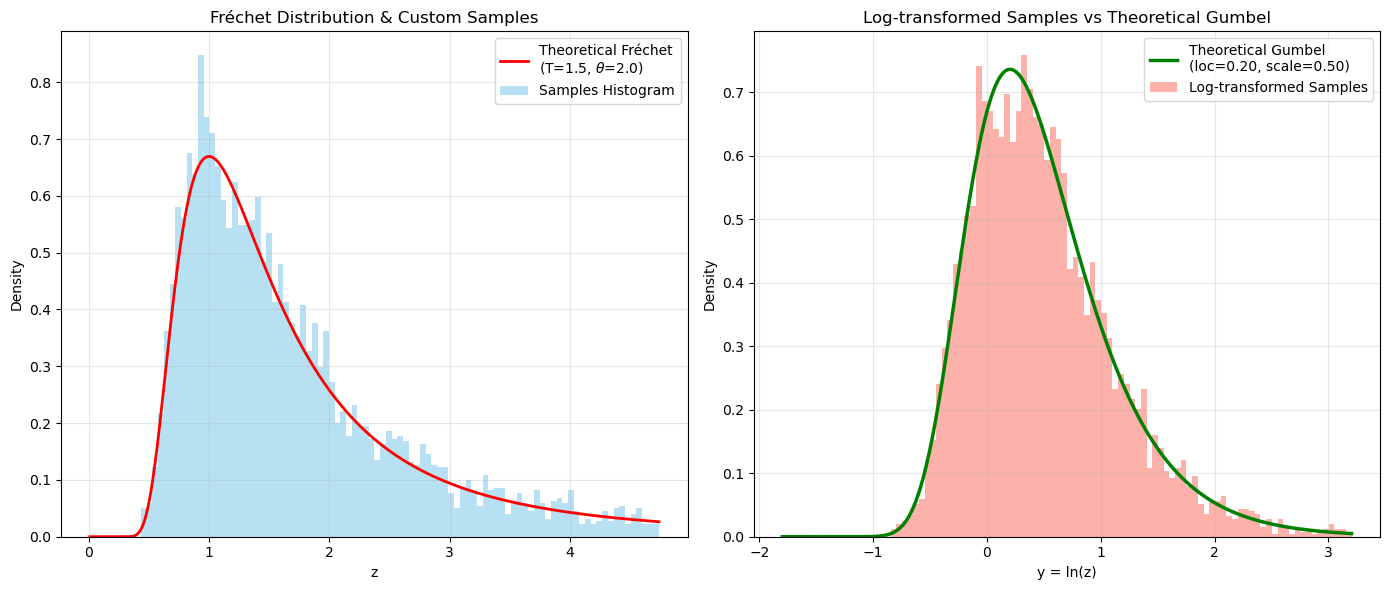

In [6]:
plot_frechet_gumbel()

## 1.4 Four Key Results
The market is perfectly competitive: $p_{ni} = \frac{\tau_{ni}c_i}{z_i}$. 
- minimize $p_{ni} = \frac{\tau_{ni}c_i}{z_i}$ with $z_i$ Fréchet distributed; 
- maximize $-\ln p_{ni} = -\ln(\tau_{ni}c_i) + \ln z_i$ with $\ln z_i$ Gumbel distributed.

1. The probability that the price of good $\omega$ in country $n$ is less than $p$ is given by 
\begin{equation*}
	G_n(p) = 1 - \exp\left\{-p^\theta\Phi_n\right\},  
\end{equation*}
where $\Phi_n=\sum_{m \in S}T_m(\tau_{nm}c_m)^{-\theta}$. 

2. The probability that $i \in S$ is the least cost provider of good $\omega \in \Omega$ to destination $n \in S$ is given by
\begin{equation*}
	\pi_{ni} = \frac{T_i \left(\tau_{ni}c_i\right)^{-\theta}}{\sum_{m \in S}T_m(\tau_{nm}c_m)^{-\theta}}. 
\end{equation*}

3. The probability that the price of good $\omega$ in country $n$ is less than $p$ **conditional on** $i$ being the provider is given by 
\begin{equation*}
	G_n(p) = 1 - \exp\left\{-p^\theta\Phi_n\right\},  
\end{equation*}

4. The price index in country $n$ is given by 
\begin{equation*}
	P_n = \gamma\left(\sum_{m \in S}T_m(\tau_{nm}c_m)^{-\theta}\right)^{-\frac{1}{\theta}}, 
\end{equation*}
where $\gamma=\left(\Gamma(\frac{1-\sigma}{\theta} + 1)\right)^{\frac{1}{1-\sigma}}$ with $\theta>\sigma-1$ for gamma function to be well defined. 

## 1.5 Gravity
Let $X_{ni}$ be total spending of country $n$ on goods from country $i$. Let $X_n=\sum_{m\in S}X_{nm}$ be country $n$'s total spending. 
Since the distribution of prices offered to an importing country $i \in S$ is independent of the origin, 
country $j$'s average expenditure per good does not depend on the source of the good. 
As a result, the fraction of goods purchased from a particular origin, $\pi_{ni}$, is equal to the fraction of $n$'s income spent on goods from country $i$, $\frac{X_{ni}}{X_n}$. 
This implies that the total expenditure of $n$ on goods from country $i$ is: 
\begin{equation*}
	X_{ni} = \frac{T_i \left(\tau_{ni}c_i\right)^{-\theta}}{\sum_{m \in S}T_m(\tau_{nm}c_m)^{-\theta}} X_n, 
\end{equation*}
which is exactly the **gravity equation**. 

- Labor is the only input: $c_i = w_i$. In equilibrium, total income in country $n$ must be equal to total spending on goods from country $i$ so 
\begin{equation*}
	w_iL_i = \sum_{n \in S}X_{ni}. 
\end{equation*}
**Trade balance** further requires $X_n = w_nL_n$ so that 
\begin{equation*}
	w_iL_i = \sum_{n \in S} \frac{T_i \left(\tau_{ni}c_i\right)^{-\theta}}{\sum_{m \in S}T_m(\tau_{nm}c_m)^{-\theta}} w_nL_n. 
\end{equation*}
This provides a system of $N-1$ independent equations **(Walras' Law)** that can be solved for wages $(w_1,\cdots,w_N)$ up to a choice of numeraire. 
Everything is as if exchanging labor **(Ricardian style)**. 

- Adding an **input-output loop** (Caliendo and Parro, 2015): $c_i = w_i^\beta P_i^{1-\beta}$. 
Imagine that intermediate goods are used to produce a composite good with a CES production function with elasticity $\sigma > 1$. 
This composite good can be either consumed or used to produce intermediate goods (input-output loop).
Each intermediate good is produced from labor and the composite good with a Cobb-Douglas technology with labor share $\beta$. 

## 1.6 Welfare
Consider again the case where $c_i = w_i$. Then $\pi_{nn} = \frac{T_n w_n^{-\theta}}{\Phi^n}$. 
Welfare is measured by real income (wage) per capita: 
$$
u_n = \frac{w_n}{P_n} = \gamma^{-1}T_n^\frac{1}{\theta}\pi_{nn}^{-\frac{1}{\theta}}. 
$$

## 1.7 Comparative Statics
As we have already established, the equilibrium needs *a system of non-linear equations* to solve for wages: 
\begin{equation}
	w_iL_i = \sum_{n \in S} \frac{T_i \left(\tau_{ni}w_i\right)^{-\theta}}{\sum_{m \in S}T_m(\tau_{nm}w_m)^{-\theta}} w_nL_n. 
\end{equation}

### Dekle, Eaton and Kortum (2008): **exact hat algebra**
Now consider an exogenous shock to labor endowments $\hat{L}_n = L_n'/L_n$, trade costs $\hat{\tau}_{ni} = \tau_{ni}'/\tau_{ni}$, or productivity $\hat{T}_i = T_i'/T_i$. Instead of solving for both the original and the new equilibrium separately, let $\hat{x} \equiv x'/x$ denote the proportional change in any variable $x$, and solve directly for changes in endogenous variables using only **observables** from the initial equilibrium (trade shares $\pi_{ni}$ and GDP $Y_n = w_nL_n$) and the **trade elasticity** $\theta$.

1. *Changes in trade shares*: From the definition $\pi_{ni} = T_i(\tau_{ni}w_i)^{-\theta}/\Phi_n$ and $\pi_{ni}' = T_i'(\tau_{ni}'w_i')^{-\theta}/\Phi_n'$,
\begin{equation*}
	\hat{\pi}_{ni} = \frac{\hat{T}_i \left(\hat{w}_i \hat{\tau}_{ni}\right)^{-\theta}}{\sum_{k \in S} \pi_{nk} \hat{T}_k \left(\hat{w}_k \hat{\tau}_{nk}\right)^{-\theta}}. 
\end{equation*}

2. *System for wage changes*: Using $\hat{Y}_n = \hat{w}_n\hat{L}_n$ and the labor market clearing condition $w_i'L_i' = \sum_n \pi_{ni}' w_n'L_n'$,
\begin{equation*}
	\hat{w}_i \hat{L}_i Y_i = \sum_{n \in S} \frac{\pi_{ni} \hat{T}_i \left(\hat{w}_i \hat{\tau}_{ni}\right)^{-\theta}}{\sum_{k \in S} \pi_{nk} \hat{T}_k \left(\hat{w}_k \hat{\tau}_{nk}\right)^{-\theta}} \hat{w}_n \hat{L}_n Y_n. 
\end{equation*}
This is a system of $N$ equations in $N$ unknowns $\hat{w}_i$, solvable up to a choice of numeraire.

3. *Welfare changes*: From $\omega_n = w_n/P_n$ and the price index formula,
\begin{equation*}
	\hat{u}_n = \left(\hat{\pi}_{nn}\right)^{-1/\theta}. 
\end{equation*}

# 2. Caliendo and Parro (2015)

## 2.1 Motivation
The EK model provides a powerful framework for understanding trade flows with many countries. However, its single-sector assumption limits its applicability for analyzing trade policies that have differential impacts across sectors (e.g., tariff reductions under NAFTA). Caliendo and Parro (2015) (henceforth CP) extends the EK framework to **multiple sectors** with **input-output linkages**, allowing for a more realistic and policy-relevant analysis of trade liberalization.

# 3. Tombe & Zhu (2019) and a Python Repliccation 

## 3.1 Motivation
From 2000 to 2007, China’s real GDP per capita nearly doubled, how?
- Widely held perception: export-led.
- Tombe & Zhu (2019): internal reform.

## 3.2 Stylized Facts

## 3.3 Quantitative Model


In [7]:
# Load employment data. 
data_emp = pd.read_csv(os.path.join(RAW_DIR, "employment_realGDP_data.csv"))

N = len(data_emp) + 1 # 30 provinces + 1 international

La = data_emp["La2000"].to_numpy().reshape(-1, 1)
Ln = data_emp["Ln2000"].to_numpy().reshape(-1, 1)
L  = La + Ln # N-1 * 1
LL = np.full((N, 1), L.sum())
LL[N-1, 0] = 2102.978587 # international population

rYLa  = data_emp["rYLa2000"].to_numpy().reshape(-1, 1)
rYLn  = data_emp["rYLn2000"].to_numpy().reshape(-1, 1)
rYL   = np.column_stack([rYLa, rYLn]).reshape(-1, 1)
rYLmu = (rYLa * La + rYLn * Ln) / L

# rYLa2005  = data_emp["rYLa2005"].to_numpy().reshape(-1, 1)
# rYLn2005  = data_emp["rYLn2005"].to_numpy().reshape(-1, 1)
# rYL2005   = np.column_stack([rYLa2005, rYLn2005]).reshape(-1, 1)
drYLa2005 = data_emp["drYLa_data"].to_numpy().reshape(-1, 1)
drYLn2005 = data_emp["drYLn_data"].to_numpy().reshape(-1, 1)
drYL2005  = np.column_stack([drYLa2005, drYLn2005]).reshape(-1, 1)

print("Employment data loaded.")

Employment data loaded.


In [8]:
# Initial and 2005 real income per worker
Via = rYLa.copy()
Vin = rYLn.copy()

Via2005 = rYLa * drYLa2005
Vin2005 = rYLn * drYLn2005

Vi      = np.column_stack([Via,       Vin]).reshape(-1, 1)
Vi2005  = np.column_stack([Via2005, Vin2005]).reshape(-1, 1)

dVi = np.vstack([Vi2005 / Vi, np.array([[1.055], [1.055]])])
temp = dVi.reshape(-1, 2)
dVia = temp[:, 0]
dVin = temp[:, 1]

In [9]:
# Load changes in trade costs. 
data_tau = pd.read_csv(os.path.join(RAW_DIR, "tauhat.csv"))
dni_ag_measured = data_tau["dni_ag"].to_numpy().reshape((N, N))
dni_na_measured = data_tau["dni_na"].to_numpy().reshape((N, N))
dni_asym_ag = data_tau["dni_asym_ag"].to_numpy().reshape((N, N))
dni_asym_na = data_tau["dni_asym_na"].to_numpy().reshape((N, N))

print("Changes in trade costs loaded.")

Changes in trade costs loaded.


In [10]:
# Load initial trade shares. 
pi_ag = pd.read_csv(os.path.join(RAW_DIR, "trade_ag.csv"), header=None).to_numpy()
pi_ag = pi_ag / pi_ag.sum(axis=1, keepdims=True)

pi_na = pd.read_csv(os.path.join(RAW_DIR, "trade_na.csv"), header=None).to_numpy()
pi_na = pi_na / pi_na.sum(axis=1, keepdims=True)

print("Initial trade shares loaded.")

Initial trade shares loaded.


*What this chunk does:*

Trade shares are stored as two $30 \times 30$ matrices (ag and na). Rows index the importer $n$, columns index the exporter $i$.

In the model:

$$\pi_{ni}^j = \frac{T_i^j (\tau_{ni}^j c_i^j)^{-\theta}}{\sum_m T_m^j (\tau_{nm}^j c_m^j)^{-\theta}}.$$

where $T_i^j$ is average productivity, $\tau_{ni}^j$ is the iceberg trade cost, $c_i^j$ is the unit production cost, and $\theta$ is the trade elasticity. 

The loaded matrices are **row-normalized** so that $\sum_i \pi_{ni}^j = 1$ for each importer $n$ and sector $j$.

In [11]:
# Load migration shares
data_mij2000 = pd.read_csv(os.path.join(RAW_DIR, "mij2000.csv"))
mij2000 = data_mij2000["mij"].to_numpy().reshape((60, 60))

data_mij2005 = pd.read_csv(os.path.join(RAW_DIR, "mij2005.csv"))
mij2005 = data_mij2005["mij"].to_numpy().reshape((60, 60))

print("Migration shares loaded.")

Migration shares loaded.


*What this chunk does:*

Migration shares are stored as a $60 \times 60$ matrix. Rows index the hukou origin $(n,j)$, columns index the work destination $(i,k)$.

In the model:

$$m_{ni}^{jk} = \frac{(\delta_{ni}^{jk} V_i^k / \mu_{ni}^{jk})^\kappa}{\sum_{k'} \sum_{i'} (\delta_{ni'}^{jk'} V_{i'}^{k'} / \mu_{ni'}^{jk'})^\kappa}.$$

The diagonal elements $m_{nn}^{jj}$ represent the fraction of workers who stay in their hukou province-sector (non-migrants).

In [12]:
# Initial Employment Vector & Hukou Registrations

L1 = np.column_stack([La, Ln]).reshape(-1, 1)
L0 = np.linalg.solve(mij2000.T, L1).reshape(-1, 1)

*What this chunk does:*

Backing out Hukou registrations $L_0$ from the relationship $L_1^T = L_0^T m_{ij}$. 

Matrix inversion is good, but directly solving for $L_0$ is better. 

- $L_0$ is a $60 \times 1$ vector giving the number of workers whose hukou is registered in each province-sector. 
- $L_1$ is a $60 \times 1$ vector of observed employment in each province-sector.

In [13]:
# Parameters

# production params
beta_ag = 0.287 # labor share of output in agriculture
beta_na = 0.219 # labor share of output in non-agriculture
eta_ag  = 0.277 # land share of output in agriculture
eta_na  = 0.025 # land share of output in non-agriculture
# different setting: sigma sums to 1 in each row
sigma = np.array([[0.397, 0.603], # ag-ag, ag-na
                  [0.063, 0.937]]) # na-ag, na-na

# same setting: 
# preference params
alpha   = 1 - 0.13 # 0.13 for housing
psi     = 0.09545 # ag goods

# dispersion params
theta   = 4.0 # distribution of varphi
kappa   = 1.5 # distribution of varepsilon

*What this chunk does:*

Specify values for parameters in 
$$y_n^j(\nu) = \varphi (L_n^j)^{\beta_j} (S_n^j)^{\eta_j} (Y_n^k)^{\sigma_{jk}} (Y_n^j)^{\sigma_{jj}}.$$
$$u_n^j = \varepsilon_n^j \left[ \left(C_n^{j,\text{ag}}\right)^{\psi^{\text{ag}}} \left(C_n^{j,\text{na}}\right)^{\psi^{\text{na}}} \right]^\alpha \left(S_n^{j,h}\right)^{1-\alpha}.$$

**Note:** Constant-returns constraint: $\beta^j + \eta^j + (1 - \beta^j - \eta^j) \sum_k \sigma^{jk} = 1$ holds for each sector $j$ **in code**.

In [14]:
# Initial total expenditures and incomes (fixed-point loop)

I0    = np.zeros((N, 1))
I     = np.ones((N, 1))
X0_ag = np.zeros((N, 1))
X_ag  = np.ones((N, 1))
X0_na = np.zeros((N, 1))
X_na  = np.ones((N, 1))

R_ag = R_na = Ir = Iu = None

while ((X0_ag - X_ag) ** 2).sum() + ((X0_na - X_na) ** 2).sum() > 1e-20: # Gauss-Seidel iteration
    
    X0_ag = X_ag.copy()
    X0_na = X_na.copy()

    R_ag = pi_ag.T @ X0_ag
    R_na = pi_na.T @ X0_na

    Ir = (beta_ag + eta_ag) * R_ag / alpha  
    Iu = (beta_na + eta_na) * R_na / alpha  

    # normalization to 1
    I = Ir + Iu 
    Ir = Ir / I.sum()
    Iu = Iu / I.sum()

    Da_r = alpha * psi * Ir # spending on agriculture goods in agriculture
    Da_u = alpha * psi * Iu # spending on agriculture goods in non-agriculture
    Dn_r = alpha * (1 - psi) * Ir # spending on non-agriculture goods in agriculture
    Dn_u = alpha * (1 - psi) * Iu # spending on non-agriculture goods in non-agriculture
    Ds_r = (1 - alpha) * Ir # spending on land in agriculture
    Ds_u = (1 - alpha) * Iu # spending on land in agriculture

    X_ag = (Da_r + Da_u
            + (1 - beta_ag - eta_ag) * sigma[0, 0] * R_ag
            + (1 - beta_na - eta_na) * sigma[1, 0] * R_na)
    X_na = (Dn_r + Dn_u
            + (1 - beta_na - eta_na) * sigma[1, 1] * R_na
            + (1 - beta_ag - eta_ag) * sigma[0, 1] * R_ag)

*What this chunk does:*

**Gauss-Seidel fixed-point iteration for expenditures and incomes**

This loop solves for the initial nominal expenditures $X_n^{ag}, X_n^{na}$ and revenues $R_n^{ag}, R_n^{na}$ that satisfy the equilibrium conditions. 

In equilibrium, total income in country $n$ must be equal to total spending on goods from country $i$ so 
\begin{equation*}
	R_i^{ag} = \sum_n X_{ni}^{ag} = \sum_n \pi_{ni}^{ag} X_n^{ag}, \qquad R_i^{na} = \sum_n X_{ni}^{na} = \sum_n \pi_{ni}^{na} X_n^{na}. 
\end{equation*}

**Income from Cobb-Douglas production**:
$$I_r = \frac{\beta^{ag} + \eta^{ag}}{\alpha} R^{ag}, \qquad I_u = \frac{\beta^{na} + \eta^{na}}{\alpha} R^{na}.$$
To show this, 
$$\begin{align*}
v_n^j L_n^j &= r_n^j \bar{S}_n^j + w_n^j L_n^j, \\
\rightarrow r_n^j \bar{S}_n^j &= (1 - \alpha) v_n^j L_n^j + \eta^j R_n^j, \\
\rightarrow v_n^j L_n^j &= (1 - \alpha) v_n^j L_n^j + \eta^j R_n^j + w_n^j L_n^j, \\
\rightarrow v_n^j L_n^j &= (\eta^j R_n^j + \beta^j R_n^j) / \alpha.
\end{align*}$$

**Final demand** (Cobb-Douglas utility):
\begin{align*}
& D_{r}^{ag} = \alpha \psi I_r, \\
& D_{u}^{ag} = \alpha \psi I_u, \\
& D_{r}^{na} = \alpha (1-\psi) I_r, \\
& D_{u}^{na} = \alpha (1-\psi) I_u, \\
& D_{s,r} = (1-\alpha) I_r, \\
& D_{s,u} = (1-\alpha) I_u.
\end{align*}

**Total expenditure** (final + intermediate demand):
$$X^{ag} = D_{ag,r} + D_{ag,u} + (1-\beta^{ag}-\eta^{ag})\sigma^{ag,ag} R^{ag} + (1-\beta^{na}-\eta^{na})\sigma^{na,ag} R^{na}$$
$$X^{na} = D_{na,r} + D_{na,u} + (1-\beta^{na}-\eta^{na})\sigma^{na,na} R^{na} + (1-\beta^{ag}-\eta^{ag})\sigma^{ag,na} R^{ag}$$

In [15]:
# Ln and La here only have N-1 rows. Append the international row.
Ln_full = np.vstack([Ln, np.zeros((1, 1))])
La_full = np.vstack([La, np.zeros((1, 1))])

Ln_full[N - 1, 0] = LL[N - 1, 0] / (1 + (beta_ag / beta_na) * (R_ag[N - 1, 0] / R_na[N - 1, 0]))
La_full[N - 1, 0] = LL[N - 1, 0] - Ln_full[N - 1, 0]

*What this chunk does:* **(To be complemented)**

Add the international employments in ag and na, implicitly assuming $w^{ag} = w^{na}$ for international. 

In [16]:
NN = 2 * (N - 1)  # 60

Vimat = np.tile(Vi, (1, NN))
Vjmat = np.tile(Vi.T, (NN, 1))

cij = (mij2000 / np.tile(np.diag(mij2000).reshape(-1, 1), (1, NN))) ** (1 / kappa) / (Vjmat / Vimat)
cij2000 = cij.copy()

Vimat2005 = np.tile(Vi2005, (1, NN))
Vjmat2005 = np.tile(Vi2005.T, (NN, 1))
cij2005 = (mij2005 / np.tile(np.diag(mij2005).reshape(-1, 1), (1, NN))) ** (1 / kappa) / (Vjmat2005 / Vimat2005)

mij_local = (cij2000 * Vjmat) ** kappa
mij_local = mij_local / mij_local.sum(axis=1, keepdims=True)
cijhat = np.ones((NN, NN))
L1base = (L0.T @ mij_local).T 
L2005  = (L0.T @ mij2005).T 

*What this chunk does:*

In [17]:
# 3. Land Rebate Adjustments to Migration Costs

M_mL_term = L1base / (np.diag(mij_local).reshape(-1, 1) * L0)
temp = M_mL_term.reshape(-1, 2)
M_mL_term_ag = temp[:, 0]
M_mL_term_na = temp[:, 1]

Cnnjj_ag = 1 + (eta_ag + (1 - alpha) * beta_ag) * M_mL_term_ag / (alpha * beta_ag)
Cnnjj_na = 1 + (eta_na + (1 - alpha) * beta_na) * M_mL_term_na / (alpha * beta_na)
Cnnjj = np.column_stack([Cnnjj_ag, Cnnjj_na]).reshape(-1, 1)
Cnijk = (1 - np.eye(NN)) * np.tile(Cnnjj, (1, NN)) * cij

Cnijk2000 = Cnijk.copy()
Cnnjj2000 = Cnnjj.copy()

M_mL_term2005 = L2005 / (np.diag(mij2005).reshape(-1, 1) * L0)
temp = M_mL_term2005.reshape(-1, 2)
M_mL_term_ag2005 = temp[:, 0]
M_mL_term_na2005 = temp[:, 1]

Cnnjj_ag2005 = 1 + (eta_ag + (1 - alpha) * beta_ag) * M_mL_term_ag2005 / (alpha * beta_ag)
Cnnjj_na2005 = 1 + (eta_na + (1 - alpha) * beta_na) * M_mL_term_na2005 / (alpha * beta_na)
Cnnjj2005 = np.column_stack([Cnnjj_ag2005, Cnnjj_na2005]).reshape(-1, 1)
Cnijk2005 = (1 - np.eye(NN)) * np.tile(Cnnjj2005, (1, NN)) * cij2005

*What this chunk does:*

In [18]:
# Symmetric trade costs

diag_pi_ag = np.diag(pi_ag).reshape(-1, 1)
diag_pi_na = np.diag(pi_na).reshape(-1, 1)

tau_ag = ((diag_pi_ag @ diag_pi_ag.T) / (pi_ag * pi_ag.T)) ** (1.0 / (2.0 * theta))
tau_na = ((diag_pi_na @ diag_pi_na.T) / (pi_na * pi_na.T)) ** (1.0 / (2.0 * theta))

/var/folders/x9/r1tbtm196kd9z19sm2rgy4ch0000gn/T/ipykernel_66686/1358329387.py:6: RuntimeWarning: divide by zero encountered in divide
  tau_ag = ((diag_pi_ag @ diag_pi_ag.T) / (pi_ag * pi_ag.T)) ** (1.0 / (2.0 * theta))


*What this chunk does:* 

Compute symmetric iceberg trade cost following Head and Ries (2001): 
$$\bar{\tau}_{ni}^{j} \equiv \sqrt{\tau_{ni}^{j}\tau_{in}^{j}} = \left( \frac{\pi_{nn}^{j}\pi_{ii}^{j}}{\pi_{ni}^{j}\pi_{in}^{j}} \right)^{1/2\theta}.$$
To show this, 
\begin{align*}
    & \pi_{ni}^j = \frac{T_i^j (\tau_{ni}^j c_i^j)^{-\theta}}{\sum_m T_m^j (\tau_{nm}^j c_m^j)^{-\theta}}, \\
    \rightarrow & (1-\pi_{ni}) T_i^j (\tau_{ni}^j c_i^j)^{-\theta} = \pi_{ni}^j \sum_{m\in S/i} T_m^j (\tau_{nm}^j c_m^j)^{-\theta}, \\
    \rightarrow & \tau_{ni}^j = \left(\frac{\pi_{ni}^j \sum_{m\in S/i} T_m^j (\tau_{nm}^j c_m^j)^{-\theta}}{(1-\pi_{ni})T_i^j(c_i^j)^{-\theta}}\right)^{-\frac{1}{\theta}}, \\
    \rightarrow & \tau_{ni}^j \tau_{in}^j = \left(\frac{(1-\pi_{ni}) (1-\pi_{in}) T_i^j(c_i^j)^{-\theta} T_n^j(c_n^j)^{-\theta}}{\pi_{ni}^j \pi_{in}^j \sum_{m\in S/i} T_m^j (\tau_{nm}^j c_m^j)^{-\theta} \sum_{m\in S/n} T_m^j (\tau_{im}^j c_m^j)^{-\theta}}\right)^{\frac{1}{\theta}}, \\
    \rightarrow & \tau_{ni}^j \tau_{in}^j = \left(\frac{(1-\pi_{ni}) (1-\pi_{in}) T_i^j(c_i^j)^{-\theta} T_n^j(c_n^j)^{-\theta}}{\pi_{ni}^j \pi_{in}^j (1-\pi_{ni})\sum_m T_m^j (\tau_{nm}^j c_m^j)^{-\theta} (1-\pi_{in})\sum_m T_m^j (\tau_{nm}^j c_m^j)^{-\theta}}\right)^{\frac{1}{\theta}}, \\
    \rightarrow & \tau_{ni}^j \tau_{in}^j = \left( \frac{\pi_{nn}^{j}\pi_{ii}^{j}}{\pi_{ni}^{j}\pi_{in}^{j}} \right)^{1/\theta}.
\end{align*}

**Note:** A warning pops up, since there exist zero trade shares (denominator). This is ok (treated as infinity). 

In [19]:
# 5. Get the Initial Equilibrium of the Model (solve the system)

from main_simulate import eqm

dTa = np.ones((N, 1))
dTn = np.ones((N, 1))
dni_ag = np.ones((N, N))
dni_na = np.ones((N, N))

params = {
    "N": N, "theta": theta,
    "beta_ag": beta_ag, "beta_na": beta_na,
    "eta_ag": eta_ag, "eta_na": eta_na,
    "dni_ag": dni_ag, "dni_na": dni_na,
    "pi_ag": pi_ag, "pi_na": pi_na,
    "L0": L0, "kappa": kappa, "alpha": alpha,
    "dTa": dTa, "dTn": dTn,
    "Vi": Vi, "mij2000": mij2000,
    "R_ag": R_ag, "R_na": R_na, "Ir": Ir, "Iu": Iu,
    "psi": psi,
    "La": La_full, "Ln": Ln_full,
    "L1base": L1base, "sigma": sigma, "Cnijk": Cnijk,
}

x0 = np.ones(6 * N)
new = fsolve(lambda x: eqm(x, params), x0, full_output=False, xtol=1e-10)

dwa = new[0:N].reshape(-1, 1)
dwn = new[N:2 * N].reshape(-1, 1)
dPa = new[2 * N:3 * N].reshape(-1, 1)
dPn = new[3 * N:4 * N].reshape(-1, 1)
dLa = new[4 * N:5 * N].reshape(-1, 1)
dLn = new[5 * N:6 * N].reshape(-1, 1)
dL = np.column_stack([dLa, dLn]).reshape(-1, 1)
dw = np.column_stack([dwa, dwn]).reshape(-1, 1)

In [20]:
# 14. Post-solve quantities 

R_ag_new = dwa * dLa * R_ag
R_na_new = dwn * dLn * R_na

Ir_new = (beta_ag + eta_ag) * R_ag_new / alpha
dIr = Ir_new / Ir
Iu_new = (beta_na + eta_na) * R_na_new / alpha
dIu = Iu_new / Iu
Da_new_r = alpha * psi * Ir_new
Da_new_u = alpha * psi * Iu_new
Dn_new_r = (alpha * (1 - psi)) * Ir_new
Dn_new_u = (alpha * (1 - psi)) * Iu_new
Ds_new_r = (1 - alpha) * Ir_new
Ds_new_u = (1 - alpha) * Iu_new

dra = dwa * dLa
drn = dwn * dLn

inside_ag = (dwa.T ** beta_ag
             * (dPa.T ** sigma[0, 0] * dPn.T ** sigma[0, 1]) ** (1 - beta_ag - eta_ag)
             * dra.T ** eta_ag
             / (dTa.T ** (1.0 / theta)))
kron_inside_ag = np.kron(inside_ag, np.ones((N, 1)))
denominator_ag = np.sum(pi_ag * (dni_ag * kron_inside_ag) ** (-theta), axis=1, keepdims=True)
pi_ag_new = (pi_ag * (dni_ag * kron_inside_ag) ** (-theta)) / np.kron(denominator_ag, np.ones((1, N)))

inside_na = (dwn.T ** beta_na
             * (dPa.T ** sigma[1, 0] * dPn.T ** sigma[1, 1]) ** (1 - beta_na - eta_na)
             * drn.T ** eta_na
             / (dTn.T ** (1.0 / theta)))
kron_inside_na = np.kron(inside_na, np.ones((N, 1)))
denominator_na = np.sum(pi_na * (dni_na * kron_inside_na) ** (-theta), axis=1, keepdims=True)
pi_na_new = (pi_na * (dni_na * kron_inside_na) ** (-theta)) / np.kron(denominator_na, np.ones((1, N)))

X_ag_new = np.linalg.solve(pi_ag_new.T, R_ag_new)
X_na_new = np.linalg.solve(pi_na_new.T, R_na_new)

dP = dPa ** psi * dPn ** (1 - psi)
dVa = dwa / (dP ** alpha * dra ** (1 - alpha))
dVn = dwn / (dP ** alpha * drn ** (1 - alpha))
dV = np.column_stack([dVa, dVn]).reshape(-1, 1)
dPa_vector = np.column_stack([dPa, dPa]).reshape(-1, 1)
dv_vector = np.column_stack([dIr / dLa, dIu / dLn]).reshape(-1, 1)

# 15. Migration Shares (post-equilibrium fixed-point)

mnn1 = np.diag(mij2000).reshape(-1, 1)
mnn0 = np.ones((NN, 1))
mij_post = None
while ((mnn0 - mnn1) ** 2).sum() > 1e-20:
    mnn0 = mnn1.copy()
    M_mL_term = (L1base * dL[0:NN]) / (mnn0 * L0)
    temp_local = M_mL_term.reshape(-1, 2)
    M_mL_term_ag = temp_local[:, 0:1]
    M_mL_term_na = temp_local[:, 1:2]
    Cnnjj_ag = 1 + (eta_ag + (1 - alpha) * beta_ag) * M_mL_term_ag / (alpha * beta_ag)
    Cnnjj_na = 1 + (eta_na + (1 - alpha) * beta_na) * M_mL_term_na / (alpha * beta_na)
    Cnnjj = np.column_stack([Cnnjj_ag, Cnnjj_na]).reshape(-1, 1)
    cij = Cnijk + np.eye(NN) * np.tile(Cnnjj, (1, NN))
    Vjmat = np.tile((dV[0:NN] * Vi).T, (NN, 1))
    mij_post = (cij * Vjmat) ** kappa
    mij_post = mij_post / mij_post.sum(axis=1, keepdims=True)
    mnn1 = np.mean(np.column_stack([np.diag(mij_post).reshape(-1, 1), mnn0]), axis=1, keepdims=True)

In [21]:
# 16. Initial Welfare Vector

omega_welfare_num = (L0 / L0.sum()) * Vi * Cnnjj2000 * np.diag(mij_post).reshape(-1, 1) ** (-1.0 / kappa)
omega_welfare = omega_welfare_num / omega_welfare_num.sum()